# Training CNN per FER-2013

Questo notebook addestra una CNN sulle immagini FER-2013 presenti nella repo.
Usa `data/original/train` per training e validation, e mantiene `data/original/test` separato per la valutazione finale.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Activation, BatchNormalization, Dense, Dropout, GlobalAveragePooling2D
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(tf.__version__)


2.21.0


## Dataset

Lo split viene fatto senza copiare file: `validation_split` separa una parte di `data/original/train` per la validazione. `data/original/test` resta intoccato.

In [2]:
current_dir = Path.cwd()
project_root = current_dir if (current_dir / "data" / "original").exists() else current_dir.parent

train_dir = project_root / "data" / "original" / "train"
test_dir = project_root / "data" / "original" / "test"

IMG_HEIGHT = 48
IMG_WIDTH = 48
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2

if not train_dir.exists():
    raise FileNotFoundError(f"Cartella training non trovata: {train_dir}")
if not test_dir.exists():
    raise FileNotFoundError(f"Cartella test non trovata: {test_dir}")

print(f"Training directory: {train_dir}")
print(f"Test directory: {test_dir}")

Training directory: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\data\original\train
Test directory: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\data\original\test


## Generatori

L augmentation viene applicata solo al training. Validation e test usano solo la normalizzazione, cosÃ¬ evitiamo data leakage.

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VALIDATION_SPLIT,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VALIDATION_SPLIT
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    class_mode="categorical",
    subset="training",
    seed=SEED
)

validation_generator = validation_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    class_mode="categorical",
    subset="validation",
    seed=SEED,
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    class_mode="categorical",
    shuffle=False
)

class_indices = train_generator.class_indices
emotion_labels = {v: k for k, v in class_indices.items()}

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights_array))

print("Classi:", class_indices)
print("Class weights:", class_weights)


Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Classi: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Class weights: {0: np.float64(1.0266404434114071), 1: np.float64(9.401555464592715), 2: np.float64(1.0009587727708533), 3: np.float64(0.5684585684585685), 4: np.float64(0.826068191627104), 5: np.float64(0.8491570541259982), 6: np.float64(1.2933160650937552)}


## Anteprima immagini

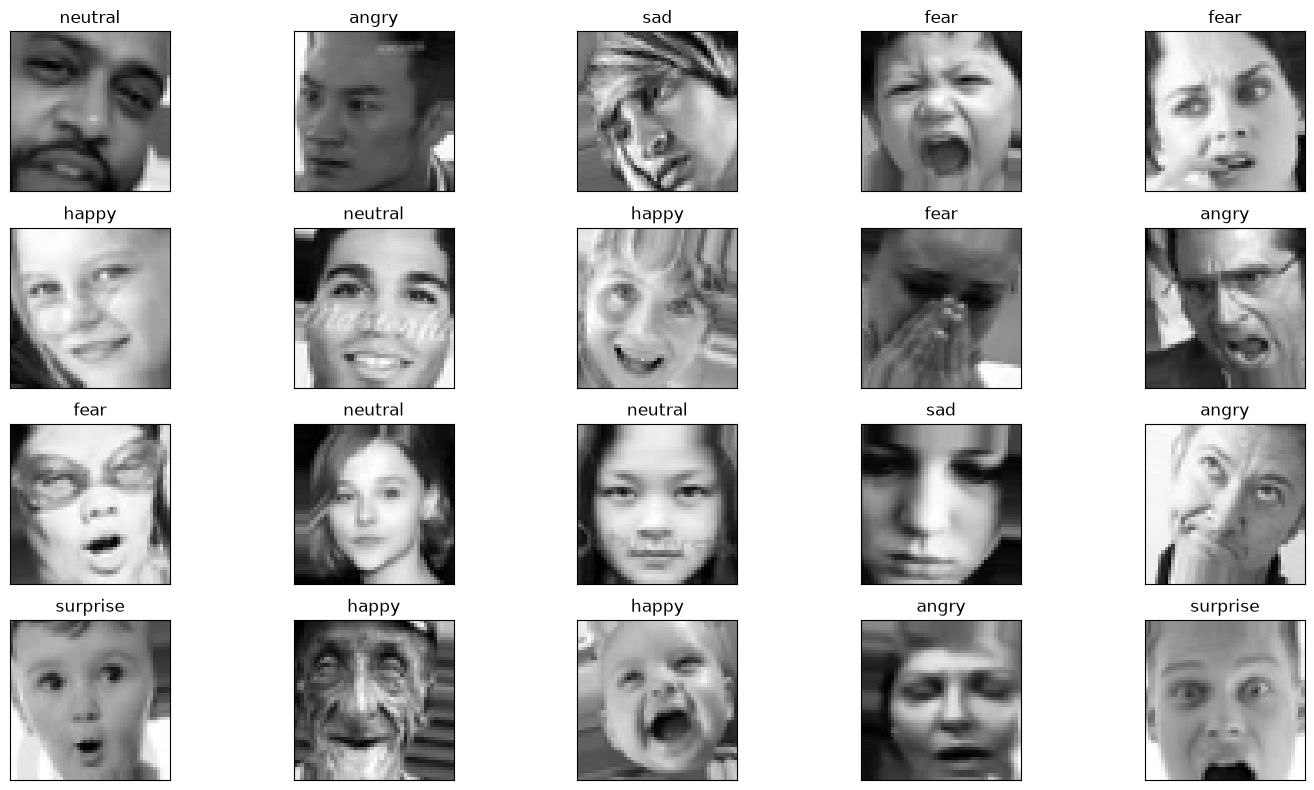

In [4]:
images, labels = next(train_generator)
num_images = min(20, len(images))

fig = plt.figure(figsize=(15, 8))
for i in range(num_images):
    ax = fig.add_subplot(4, 5, i + 1, xticks=[], yticks=[])
    class_index = np.argmax(labels[i])
    ax.imshow(images[i].reshape(IMG_HEIGHT, IMG_WIDTH), cmap="gray")
    ax.set_title(emotion_labels[class_index])

plt.tight_layout()
plt.show()

## Modello CNN

In [5]:
input_shape = (IMG_HEIGHT, IMG_WIDTH, 1)

modelCNN = Sequential([
    Input(shape=input_shape),

    Conv2D(32, (3, 3), padding="same"),
    Activation("relu"),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding="same"),
    Activation("relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding="same"),
    Activation("relu"),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding="same"),
    Activation("relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.30),

    Conv2D(128, (3, 3), padding="same"),
    Activation("relu"),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding="same"),
    Activation("relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.35),

    GlobalAveragePooling2D(),

    Dense(128, activation="relu"),
    Dropout(0.50),

    Dense(train_generator.num_classes, activation="softmax")
])

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4)

modelCNN.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

modelCNN.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 305,639 (1.17 MB)

 Trainable params: 304,743 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

## Training

In [6]:
models_dir = project_root / "models"
models_dir.mkdir(exist_ok=True)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint(str(models_dir / "best_cnn.keras"), monitor="val_loss", save_best_only=True)
]

history = modelCNN.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=callbacks,
    class_weight=class_weights
)


Epoch 1/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 55s 73ms/step - accuracy: 0.1724 - auc: 0.5507 - loss: 1.9961 - val_accuracy: 0.1226 - val_auc: 0.5603 - val_loss: 1.9490 - learning_rate: 3.0000e-04
Epoch 2/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 54s 75ms/step - accuracy: 0.1849 - auc: 0.5832 - loss: 1.9126 - val_accuracy: 0.2454 - val_auc: 0.6330 - val_loss: 1.8595 - learning_rate: 3.0000e-04
Epoch 3/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 53s 73ms/step - accuracy: 0.2376 - auc: 0.6295 - loss: 1.8525 - val_accuracy: 0.3099 - val_auc: 0.6837 - val_loss: 1.8109 - learning_rate: 3.0000e-04
Epoch 4/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 53s 74ms/step - accuracy: 0.2874 - auc: 0.6740 - loss: 1.7724 - val_accuracy: 0.3038 - val_auc: 0.7041 - val_loss: 1.7221 - learning_rate: 3.0000e-04
Epoch 5/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 53s 74ms/step - accuracy: 0.3087 - auc: 0.7042 - loss: 1.7021 - val_accuracy: 0.3794 - val_auc: 0.7686 - val_loss: 1.5752 - learning_rate: 3.0000e-04
Epoch 6/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 53s 74ms/s

## Curve di apprendimento

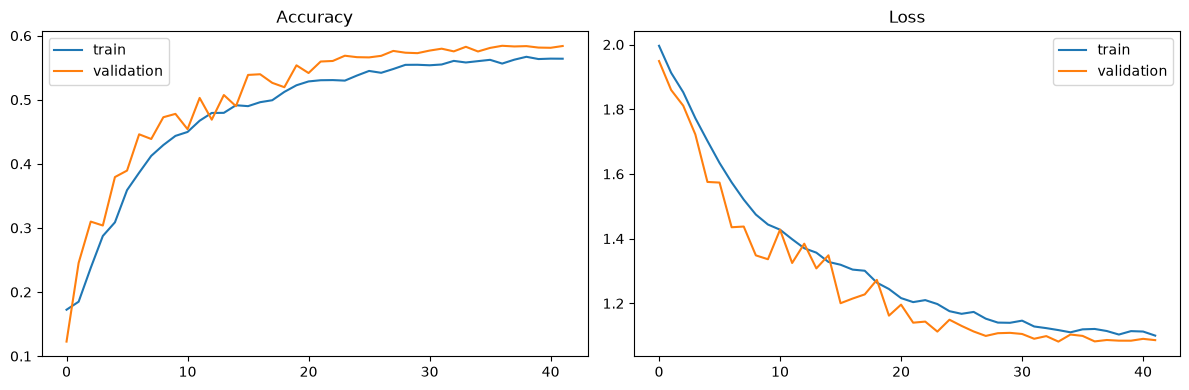

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Valutazione finale sul test set

In [8]:
test_loss, test_accuracy, test_auc = modelCNN.evaluate(test_generator)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test AUC: {test_auc:.4f}")

y_true = test_generator.classes
y_pred_proba = modelCNN.predict(test_generator)
y_pred = np.argmax(y_pred_proba, axis=1)

target_names = [emotion_labels[i] for i in range(len(emotion_labels))]
print(classification_report(y_true, y_pred, target_names=target_names))
print(confusion_matrix(y_true, y_pred))

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5846 - auc: 0.9009 - loss: 1.0841
Test loss: 1.0841
Test accuracy: 0.5846
Test AUC: 0.9009
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step
              precision    recall  f1-score   support

       angry       0.48      0.53      0.51       958
     disgust       0.27      0.68      0.38       111
        fear       0.47      0.17      0.24      1024
       happy       0.86      0.81      0.83      1774
     neutral       0.48      0.69      0.57      1233
         sad       0.49      0.38      0.43      1247
    surprise       0.64      0.83      0.72       831

    accuracy                           0.58      7178
   macro avg       0.53      0.58      0.53      7178
weighted avg       0.59      0.58      0.57      7178

[[ 507   71   43   36  172   84   45]
 [  23   75    1    1    4    4    3]
 [ 163   41  169   38  194  215  204]
 [  53   26   19 1437  135   40   64]
 [  92   15   27   65  849  147   38]
 [ 179   46   67   68  3